# Análisis de datos - TP Final

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import kagglehub
from scipy import stats as st
from scipy.stats import describe

## Descargamos dataset

In [2]:
# Download latest version
path = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")

print("Path to dataset files:", path)

100%|██████████| 238M/238M [00:09<00:00, 27.0MB/s] 

Extracting files...


Path to dataset files: /home/jbmild/.cache/kagglehub/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/versions/873


## Cargamos el dataframe

In [5]:
df = pd.read_csv(path + "/TMDB_movie_dataset_v11.csv", na_values='sin especificar', encoding='ISO-8859-1')
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [6]:
df.describe()


,id,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.385081e+06,1.385081e+06,1.385081e+06,1.385081e+06,1.385081e+06,1.385081e+06,1.385081e+06
mean,8.803176e+05,1.587898e+00,1.549130e+01,6.257401e+05,4.436814e+01,2.396067e+05,1.035865e+00
std,4.678101e+05,2.876492e+00,2.886247e+02,1.923276e+07,6.078438e+01,5.103126e+06,6.887492e+00
min,2.000000e+00,0.000000e+00,0.000000e+00,-1.200000e+01,-2.800000e+01,0.000000e+00,0.000000e+00
25%,4.846720e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e-01
50%,8.963110e+05,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01,0.000000e+00,6.000000e-01
75%,1.291095e+06,2.000000e+00,1.000000e+00,0.000000e+00,8.500000e+01,0.000000e+00,7.310000e-01
max,1.650326e+06,1.000000e+01,3.449500e+04,5.000000e+09,1.440000e+04,1.000000e+09,2.994357e+03


In [7]:
df.shape

(1385081, 24)

In [8]:
# Contar la proporción de valores nulos en cada columna
df.isna().sum()  

id                            0
title                        18
vote_average                  0
vote_count                    0
status                        0
release_date             298151
revenue                       0
runtime                       0
adult                         0
backdrop_path           1038279
budget                        0
homepage                1242180
imdb_id                  724332
original_language             0
original_title               18
overview                 314984
popularity                    0
poster_path              485487
tagline                 1192212
genres                   602732
production_companies     791169
production_countries     663893
spoken_languages         637709
keywords                1039447
dtype: int64

In [21]:
# Calcular la proporción de valores nulos en cada columna
df.isna().mean().round(4)*100

id                       0.00
title                    0.00
vote_average             0.00
vote_count               0.00
status                   0.00
release_date            21.53
revenue                  0.00
runtime                  0.00
adult                    0.00
backdrop_path           74.96
budget                   0.00
homepage                89.68
imdb_id                 52.30
original_language        0.00
original_title           0.00
overview                22.74
popularity               0.00
poster_path             35.05
tagline                 86.08
genres                  43.52
production_companies    57.12
production_countries    47.93
spoken_languages        46.04
keywords                75.05
dtype: float64

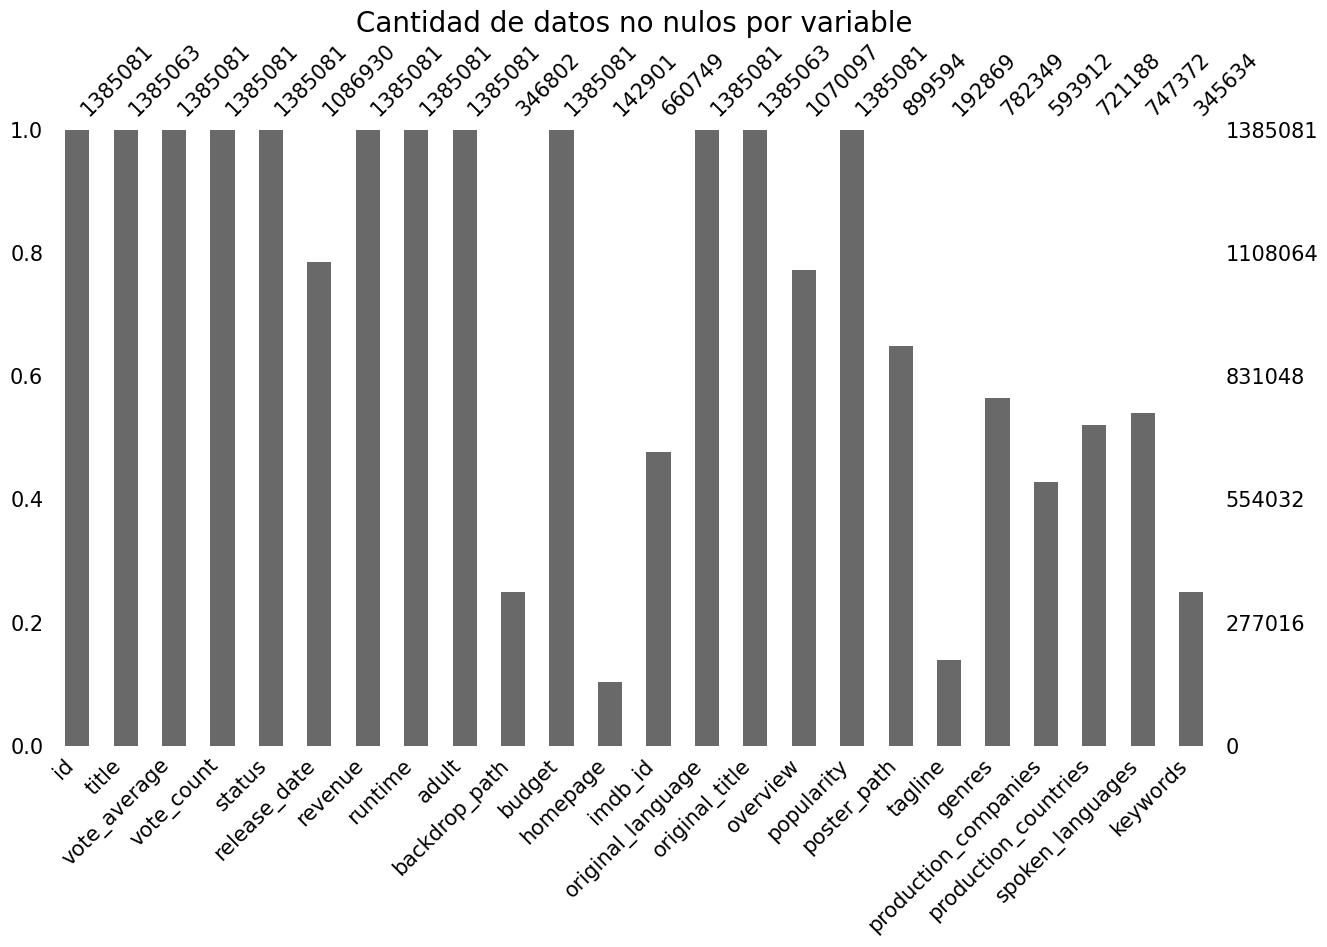

In [23]:
msno.bar(df, fontsize=15, figsize=(15,8))
plt.title("Cantidad de datos no nulos por variable", fontsize=20)
plt.show()

<Axes: >

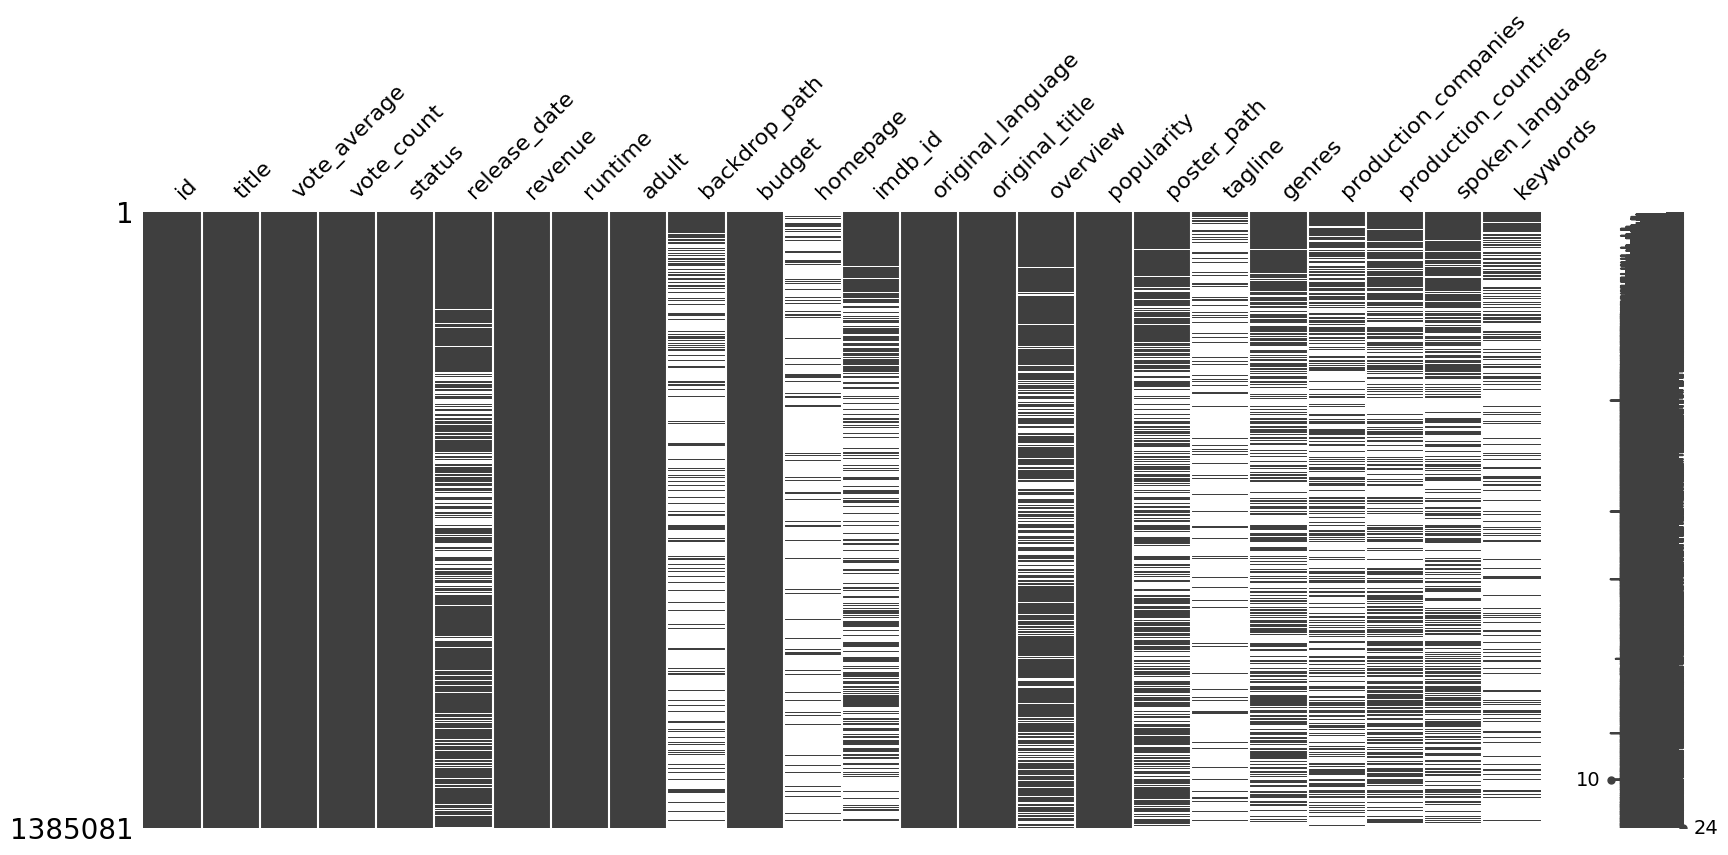

In [14]:
# Matriz de valores faltantes
msno.matrix(df, figsize=(20,8))

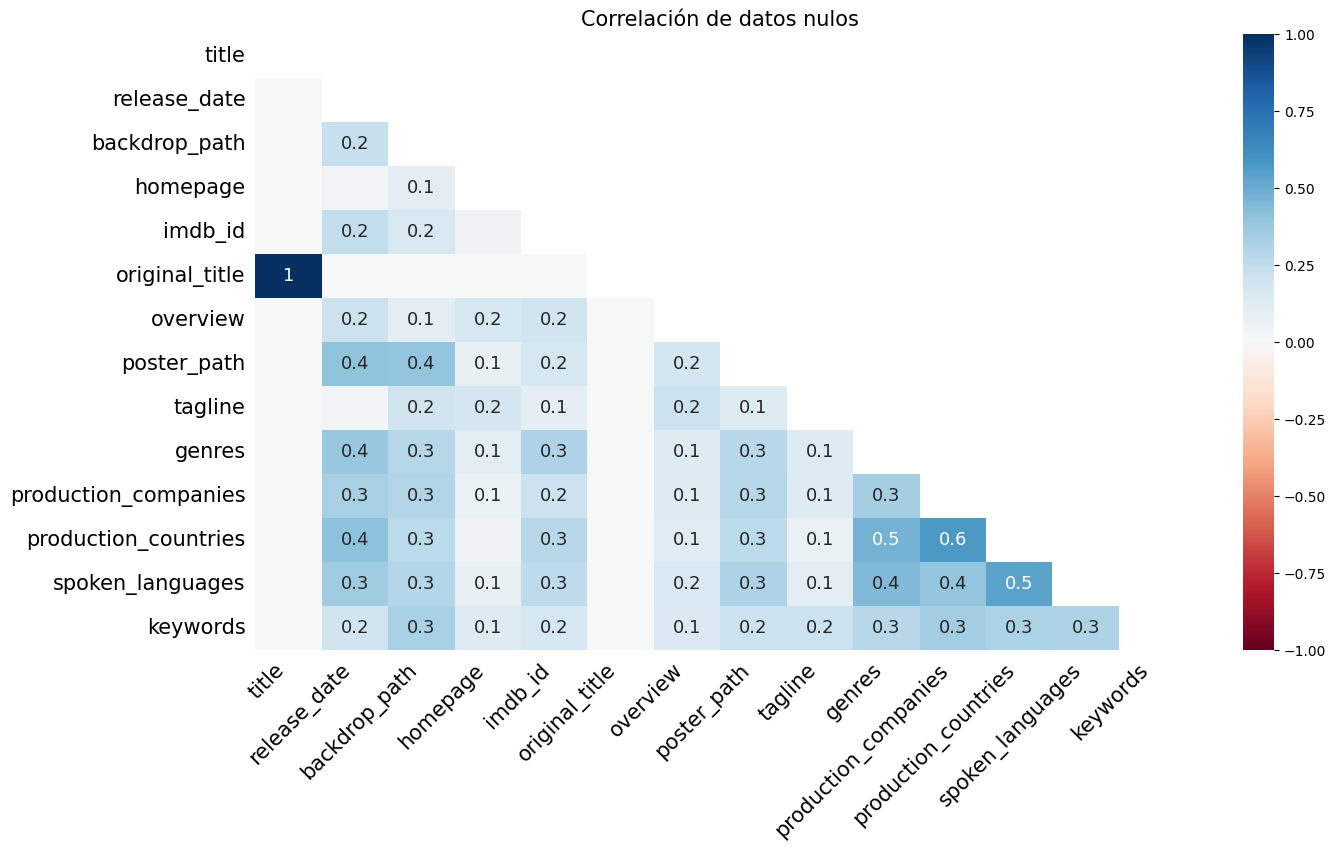

In [24]:
msno.heatmap(df, fontsize=15, figsize=(15,8))
plt.title("Correlación de datos nulos", fontsize=15)
plt.show()

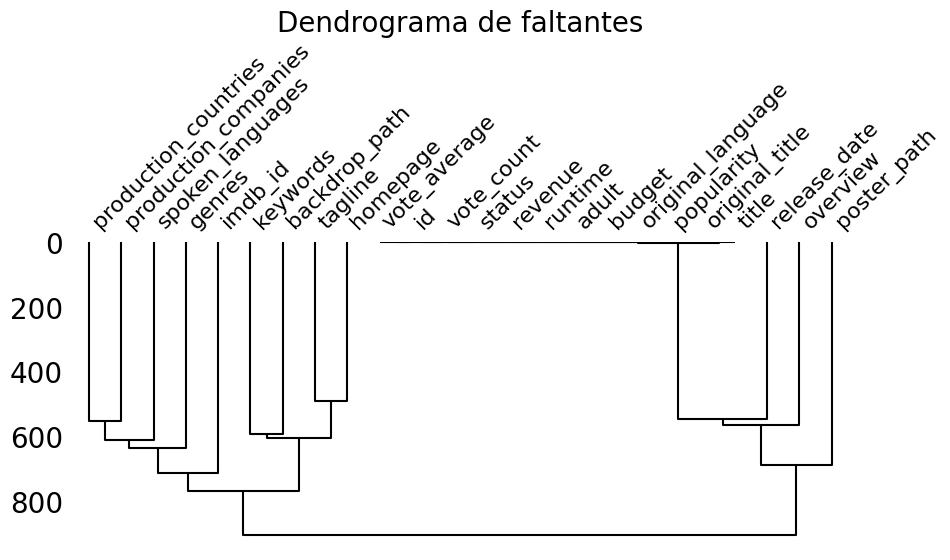

In [15]:
msno.dendrogram(df, figsize=(10,4))
plt.title('Dendrograma de faltantes', fontsize=20)
plt.show()

## Exploramos variables categóricas

In [16]:
df['status'].unique()

array(['Released', 'Planned', 'Post Production', 'In Production',
       'Rumored', 'Canceled'], dtype=object)

In [17]:
df['adult'].unique()

array([False,  True])

In [18]:
df['original_language'].unique()

array(['en', 'ko', 'fr', 'ja', 'it', 'es', 'pl', 'pt', 'hi', 'tr', 'da',
       'de', 'cn', 'id', 'zh', 'sv', 'el', 'ru', 'sr', 'fa', 'th', 'ar',
       'no', 'nb', 'fi', 'te', 'la', 'nl', 'hu', 'he', 'is', 'ro', 'gl',
       'uk', 'eu', 'et', 'bs', 'bn', 'xx', 'sh', 'km', 'cs', 'tn', 'ml',
       'mk', 'ga', 'hy', 'ku', 'ka', 'ta', 'kn', 'tl', 'vi', 'ca', 'dz',
       'sw', 'kk', 'wo', 'sk', 'lv', 'mi', 'bo', 'ps', 'mn', 'lt', 'ur',
       'sl', 'sc', 'af', 'hr', 'se', 'iu', 'ms', 'bm', 'mr', 'bg', 'am',
       'cy', 'lo', 'xh', 'qu', 'yi', 'yo', 'sq', 'pa', 'eo', 'gu', 'zu',
       'st', 'ne', 'ak', 'mt', 'rw', 'as', 'ay', 'ln', 'si', 'mo', 'ff',
       'so', 'ky', 'ik', 'ab', 'az', 'kl', 'jv', 'fo', 'li', 'sn', 'my',
       'tg', 'su', 'ks', 'ht', 'lb', 'sm', 'tk', 'sa', 'rm', 'ha', 'fy',
       'bi', 'ny', 'or', 'om', 'be', 'gd', 'mg', 'uz', 'cr', 'nn', 'mh',
       'co', 'gn', 'ia', 'tw', 'tt', 'nv', 'os', 'ug', 'ig', 'sg', 'nd',
       'kw', 'ty', 'dv', 'ba', 'sd', 'oc', 'ie', 'n

In [20]:
sorted(
    df['genres']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

['Action',
 'Adventure',
 'Animation',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Family',
 'Fantasy',
 'History',
 'Horror',
 'Music',
 'Mystery',
 'Romance',
 'Science Fiction',
 'TV Movie',
 'Thriller',
 'War',
 'Western']